In [1]:
import fargopy as fp
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

%load_ext autoreload
%autoreload 2


Running FARGOpy version 0.3.15


In [2]:
fp.Simulation.download_precomputed('p3disoj')


Precomputed output directory '/tmp/p3disoj' already exist


'/tmp/p3disoj'

In [3]:
#sim = fp.Simulation(output_dir='/home/jupitergeci/fargowork/data/fargo_data')
sim = fp.Simulation(output_dir='/tmp/p3disoj')

Your simulation is now connected with '/home/jupitergeci/fargo3d/'
Now you are connected with output directory '/tmp/p3disoj'
Found a variables.par file in '/tmp/p3disoj', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 128 [[0, -3.117048960983623], [-1, 3.117048960983623]]
	Variable r: 64 [[0, 0.5078125], [-1, 1.4921875]]
	Variable theta: 32 [[0, 1.4231400767948967], [-1, 1.5684525767948965]]
Number of snapshots in output directory: 11
Planets found in summary.dat:
  Name: Jupiter, Distance: 1.0, Mass: 0.001
Configuration variables and domains load into the object. See e.g. <sim>.vars


In [4]:
# Load the 1D gas density field from the simulation
dens1d = sim.load_field(
    fields='gasdens',
    slice="phi=0,theta=1.56",
    snapshot=10,
    interpolate=True)

In [5]:
r = np.sqrt(dens1d.df.var1_mesh[0]**2 + dens1d.df.var2_mesh[0]**2+dens1d.df.var3_mesh[0]**2)

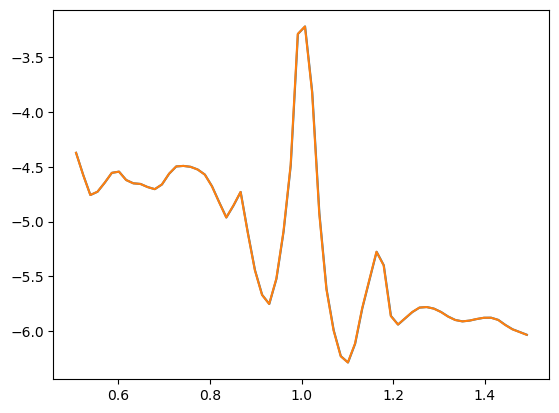

In [6]:
plt.plot(r,np.log(dens1d.df.gasdens_mesh[0]))
plt.plot(dens1d.df.var1_mesh[0],np.log(dens1d.df.gasdens_mesh[0]))


In [7]:
# Load the 2D gas density field from the simulation
dens2d = sim.load_field(
    fields='gasdens',
    snapshot=(0,10),
    slice='phi=0',
    interpolate=True)

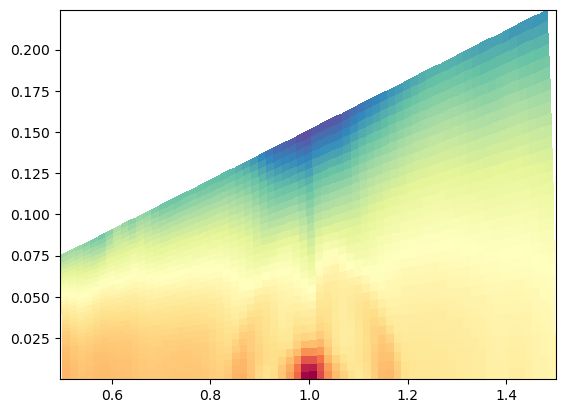

In [8]:
plt.pcolormesh(dens2d.df.var1_mesh[4], dens2d.df.var3_mesh[4], np.log(dens2d.df.gasdens_mesh[4]), cmap='Spectral_r')

In [9]:
# Load the 3D gas density field from the simulation
dens3d = sim.load_field(
    fields='gasdens',
    snapshot=10,
    interpolate=True)

Loading 3D density data 


(-1.6409073822285203,
 1.6409073822285203,
 -1.6409073822285203,
 1.6409073822285203,
 -1.1203199141300642,
 1.3410411592127163)

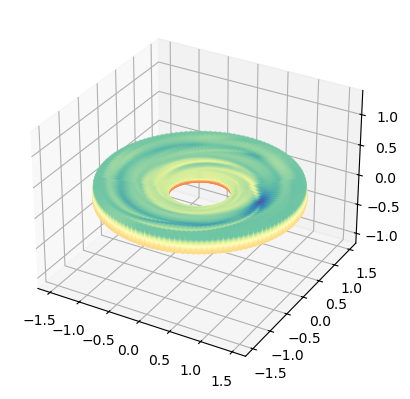

In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np


# Create a figure and a 3D axes object
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter3D(dens3d.df.var1_mesh[0].flatten(),
             dens3d.df.var2_mesh[0].flatten(),
             dens3d.df.var3_mesh[0].flatten(),
             c=np.log(dens3d.df.gasdens_mesh[0].flatten()), cmap='Spectral_r')
ax.axis('equal')

In [11]:
xmin,xmax = dens2d.df.var1_mesh[0].min(), dens2d.df.var1_mesh[0].max()
ymin,ymax = dens2d.df.var2_mesh[0].min(), dens2d.df.var2_mesh[0].max()
zmin,zmax = dens2d.df.var3_mesh[0].min(), dens2d.df.var3_mesh[0].max()
xs=np.linspace(xmin, xmax, 400)
ys=np.linspace(ymin, ymax, 400)
zs=np.linspace(zmin, zmax, 400)

X, Z = np.meshgrid(xs, zs)


In [12]:
density=dens2d.evaluate(
    time=5.8,
    var1=1.3,
    var3=0.14,
    interpolator='griddata',
    method='linear')

Running FARGOpy version 0.3.15
Running FARGOpy version 0.3.15Running FARGOpy version 0.3.15

Running FARGOpy version 0.3.15Running FARGOpy version 0.3.15

Running FARGOpy version 0.3.15
Running FARGOpy version 0.3.15
Running FARGOpy version 0.3.15


In [15]:
density=dens2d.evaluate(
    time=10,
    var1=X,
    var3=Z,
    interpolator='griddata',
    method='linear')

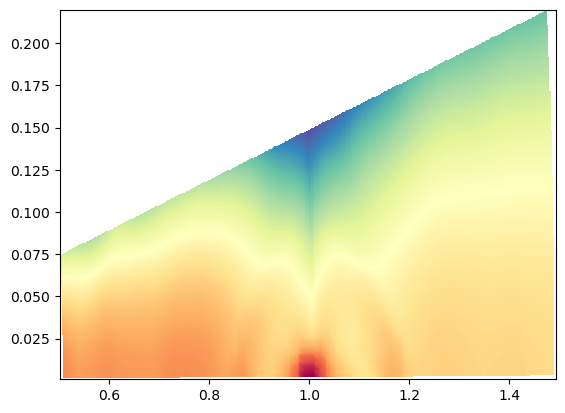

In [16]:
plt.pcolormesh(X, Z, np.log(density), cmap='Spectral_r')

In [17]:
dens1d.df.gasdens_mesh[0].shape

(64,)

In [18]:
dens1d_intp=dens1d.evaluate(
    time=10,
    var1=1.3)

In [19]:
rmin,rmax=0.1,1.8
rs = np.linspace(rmin, rmax, 100)
r = np.sqrt(dens1d.df.var1_mesh[0]**2 + dens1d.df.var2_mesh[0]**2+dens1d.df.var3_mesh[0]**2)


In [22]:
density=dens3d.evaluate(
    time=10,
    var1=1,
    var2=0.02,
    var3=0.04,
    interpolator='griddata',
    method='nearest')